# Section 1. Asia Network: Extracting the Graph Structure

The Asia network is a standard Bayesian network benchmark that we use as a motivating graphical example. Its BIF (Bayesian Interchange Format) representation specifies the variables, conditional dependencies, and parent-child relationships in the directed acyclic graph (DAG).

In this section, we parse the Asia network from its BIF representation and define utility functions to extract its edges, skeleton, and $v$-structures. These graphical features are central to the study of Markov equivalence.

Asia network data from: https://www.bnlearn.com/bnrepository/discrete-small.html

In [2]:
import re
from collections import defaultdict

In [3]:
# ------------------------------------------------------------
# Asia network in BIF format
# ------------------------------------------------------------
asia_bif = """
network unknown {
}
variable asia {
  type discrete [ 2 ] { yes, no };
}
variable tub {
  type discrete [ 2 ] { yes, no };
}
variable smoke {
  type discrete [ 2 ] { yes, no };
}
variable lung {
  type discrete [ 2 ] { yes, no };
}
variable bronc {
  type discrete [ 2 ] { yes, no };
}
variable either {
  type discrete [ 2 ] { yes, no };
}
variable xray {
  type discrete [ 2 ] { yes, no };
}
variable dysp {
  type discrete [ 2 ] { yes, no };
}
probability ( asia ) {
  table 0.01, 0.99;
}
probability ( tub | asia ) {
  (yes) 0.05, 0.95;
  (no) 0.01, 0.99;
}
probability ( smoke ) {
  table 0.5, 0.5;
}
probability ( lung | smoke ) {
  (yes) 0.1, 0.9;
  (no) 0.01, 0.99;
}
probability ( bronc | smoke ) {
  (yes) 0.6, 0.4;
  (no) 0.3, 0.7;
}
probability ( either | lung, tub ) {
  (yes, yes) 1.0, 0.0;
  (no, yes) 1.0, 0.0;
  (yes, no) 1.0, 0.0;
  (no, no) 0.0, 1.0;
}
probability ( xray | either ) {
  (yes) 0.98, 0.02;
  (no) 0.05, 0.95;
}
probability ( dysp | bronc, either ) {
  (yes, yes) 0.9, 0.1;
  (no, yes) 0.7, 0.3;
  (yes, no) 0.8, 0.2;
  (no, no) 0.1, 0.9;
}
"""

# ------------------------------------------------------------
# Parse BIF
# ------------------------------------------------------------
def parse_bif_edges(bif_text: str):
    prob_pattern = re.compile(r'probability\s*\(\s*([A-Za-z_]\w*)\s*(?:\|\s*([^)]+))?\)')
    variables = re.findall(r'variable\s+([A-Za-z_]\w*)\s*{', bif_text)

    edges = []
    parents = defaultdict(list)

    for match in prob_pattern.finditer(bif_text):
        child = match.group(1)
        parent_str = match.group(2)

        if parent_str:
            ps = [p.strip() for p in parent_str.split(",")]
            parents[child] = ps
            for p in ps:
                edges.append((p, child))
        else:
            parents[child] = []

    return variables, edges, parents

# ------------------------------------------------------------
# Graph utilities
# ------------------------------------------------------------
def get_skeleton(edges):
    return {tuple(sorted((u, v))) for u, v in edges}

def get_vstructures(parents, edges):
    adj_undirected = get_skeleton(edges)
    v_structures = []

    for child, ps in parents.items():
        if len(ps) < 2:
            continue
        for i in range(len(ps)):
            for j in range(i + 1, len(ps)):
                a, b = ps[i], ps[j]
                if tuple(sorted((a, b))) not in adj_undirected:
                    v_structures.append((a, child, b))
    return v_structures

def parents_from_edges(edges):
    p = defaultdict(list)
    nodes = set()
    for u, v in edges:
        p[v].append(u)
        nodes.add(u)
        nodes.add(v)
    for n in nodes:
        p[n] = p[n]
    return p

def markov_equivalent(edges1, edges2):
    sk1 = get_skeleton(edges1)
    sk2 = get_skeleton(edges2)

    p1 = parents_from_edges(edges1)
    p2 = parents_from_edges(edges2)

    vs1 = set(get_vstructures(p1, edges1))
    vs2 = set(get_vstructures(p2, edges2))

    return sk1 == sk2 and vs1 == vs2


We now apply the parsing and graph utility functions to the Asia network in order to extract its variables, directed edges, skeleton, and $v$-structures.

In [4]:
asia_variables, asia_edges, asia_parents = parse_bif_edges(asia_bif)

print("Variables:")
print(asia_variables)

print("\nAsia edges:")
for e in asia_edges:
    print(e)

print("\nAsia skeleton:")
for e in sorted(get_skeleton(asia_edges)):
    print(e)

print("\nAsia v-structures:")
for vs in get_vstructures(asia_parents, asia_edges):
    print(vs)

Variables:
['asia', 'tub', 'smoke', 'lung', 'bronc', 'either', 'xray', 'dysp']

Asia edges:
('asia', 'tub')
('smoke', 'lung')
('smoke', 'bronc')
('lung', 'either')
('tub', 'either')
('either', 'xray')
('bronc', 'dysp')
('either', 'dysp')

Asia skeleton:
('asia', 'tub')
('bronc', 'dysp')
('bronc', 'smoke')
('dysp', 'either')
('either', 'lung')
('either', 'tub')
('either', 'xray')
('lung', 'smoke')

Asia v-structures:
('lung', 'either', 'tub')
('bronc', 'dysp', 'either')


The output identifies the directed edges of the Asia network, together with its skeleton and $v$-structures. These are precisely the graphical quantities used in the Verma--Pearl characterization of Markov equivalence: two DAGs are Markov equivalent if and only if they have the same skeleton and the same set of $v$-structures.

This example provides a concrete DAG on which we can illustrate structural properties such as Markov equivalence.

# Section 2. A Simple Example of Markov Equivalence

To illustrate Markov equivalence, we construct two simple directed acyclic graphs (DAGs) on three nodes:

$$
A \to B \to C,
\qquad
A \leftarrow B \leftarrow C.
$$

Although the edge directions differ, these two graphs share the same skeleton and have no $v$-structures. Therefore, they are Markov equivalent under the Verma--Pearl criterion.

We visualize both graphs and verify their equivalence computationally.

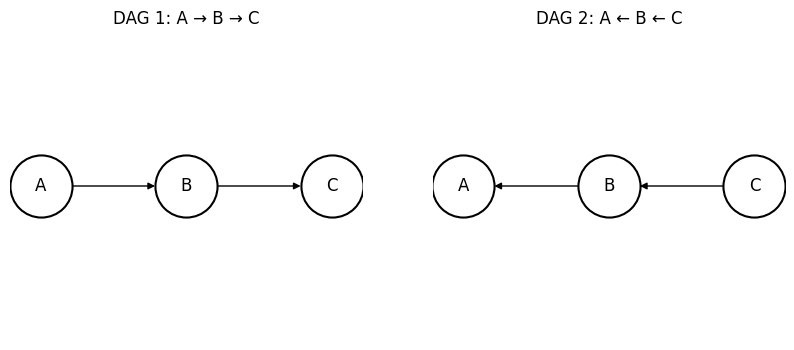

Equivalent? True
Skeleton: {('B', 'C'), ('A', 'B')}
V-structures DAG1: []
V-structures DAG2: []


In [7]:
import networkx as nx
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Define two DAGs
# ------------------------------------------------------------
edges1 = [('A', 'B'), ('B', 'C')]          # A -> B -> C
edges2 = [('B', 'A'), ('C', 'B')]          # A <- B <- C

plt.figure(figsize=(10, 4))

# ------------------------------------------------------------
# DAG 1
# ------------------------------------------------------------
plt.subplot(1, 2, 1)

pos1 = {'A': (0, 0), 'B': (1, 0), 'C': (2, 0)}

nx.draw(
    G1, pos1,
    with_labels=True,
    node_size=2000,
    node_color='white',
    edgecolors='black',
    linewidths=1.5,
    arrows=True
)

plt.title("DAG 1: A → B → C")

# ------------------------------------------------------------
# DAG 2
# ------------------------------------------------------------
plt.subplot(1, 2, 2)

pos2 = {'A': (0, 0), 'B': (1, 0), 'C': (2, 0)}

nx.draw(
    G2, pos2,
    with_labels=True,
    node_size=2000,
    node_color='white',
    edgecolors='black',
    linewidths=1.5,
    arrows=True
)

plt.title("DAG 2: A ← B ← C")

plt.show()

# ------------------------------------------------------------
# Check Markov equivalence
# ------------------------------------------------------------
print("Equivalent?", markov_equivalent(edges1, edges2))

print("Skeleton:", get_skeleton(edges1))
print("V-structures DAG1:", get_vstructures(parents_from_edges(edges1), edges1))
print("V-structures DAG2:", get_vstructures(parents_from_edges(edges2), edges2))

Both DAGs have no $v$-structures, since no node has two incoming edges. Hence, their equivalence follows directly from having identical skeletons and empty $v$-structure sets.

This example demonstrates that edge orientation alone does not determine the conditional independence structure. Instead, Markov equivalence depends only on the skeleton and $v$-structures of the graph.

The key message here is that two DAGs are equivalent $\iff$ same skeleton + same v-structures

# Section 3. Algebraic Representation of Graphical Models

The graphical examples above illustrate that different directed acyclic graphs (DAGs) can encode the same conditional independence structure. This raises a natural question: how can we represent these equivalence classes in a more structured and computationally tractable way?

Algebraic statistics provides a framework for this purpose by associating polynomial ideals to graphical models. In this setting, conditional independence relations correspond to polynomial constraints, and graphical equivalence can be studied through algebraic properties of these polynomials.

We briefly introduce the key algebraic objects that will be used in the sequel.

Let $R = \mathbb{F}[x_1, \dots, x_n]$ be a polynomial ring over a field $\mathbb{F}$.

- An **ideal** $I \subseteq R$ is a set of polynomials closed under addition and multiplication by arbitrary elements of $R$:
$$
I = \langle f_1, \dots, f_k \rangle = \left\{ \sum_{i=1}^k q_i f_i : q_i \in R \right\}.
$$

- A **Gröbner basis** $G = \{g_1, \dots, g_m\}$ for an ideal $I$ is a generating set with special computational properties that depend on a chosen monomial order.

The key advantage of Gröbner bases is that they allow us to perform algorithmic computations in polynomial rings, analogous to long division in the univariate case.

A central operation in this framework is polynomial reduction. Given a set of polynomials $G = \{g_1, \dots, g_k\}$, we can divide a polynomial $f$ by $G$ using the multivariate division algorithm to obtain:
$$
f = \sum_{i=1}^k q_i g_i + r,
$$
where no term of the remainder $r$ is divisible by the leading terms of the $g_i$.

The remainder $r$ is called the **normal form** of $f$ with respect to $G$, denoted $\mathrm{NF}_G(f)$.

If $G$ is a Gröbner basis, then:
$$
f \in \langle G \rangle \iff \mathrm{NF}_G(f) = 0.
$$

This provides an effective method for testing ideal membership, which will serve as the computational backbone of our demonstration.

In [8]:
# ------------------------------------------------------------
# Symbolic setup
# ------------------------------------------------------------
import sympy as sp

# define variables
x, y = sp.symbols('x y')

# define generators of an ideal
g1 = x**2 - y
g2 = x*y - 1

print("Generators:")
print("g1 =", g1)
print("g2 =", g2)

Generators:
g1 = x**2 - y
g2 = x*y - 1


We now compute a Gröbner basis for the ideal generated by these polynomials. In practice, this is done using Buchberger’s Algorithm, which is implemented internally in symbolic computation libraries.

In [9]:
G = sp.groebner([g1, g2], x, y, order='lex')

print("Groebner basis:")
for g in G:
    print(g)

Groebner basis:
x - y**2
y**3 - 1


Using the computed Gröbner basis, we can reduce a polynomial and determine whether it belongs to the ideal.

In [10]:
# test polynomial
f = x**3 - x

# reduce f modulo the Groebner basis
remainder = G.reduce(f)[1]

print("f =", f)
print("Remainder =", remainder)

f = x**3 - x
Remainder = 1 - y**2


The remainder represents the normal form $\mathrm{NF}_G(f)$. If the remainder is zero, then $f$ belongs to the ideal generated by $G$; otherwise, it does not.

This computational mechanism mirrors the theoretical role of the multivariate division algorithm and provides a practical way to work with polynomial ideals.

# Section 4. From Graphs to Algebra: A Toy Correspondence

The previous sections introduced graphical models and algebraic tools separately. We now illustrate how a graphical structure can be translated into polynomial relations, forming a bridge between directed acyclic graphs (DAGs) and algebraic ideals.

In algebraic statistics, conditional independence relations can be encoded as polynomial constraints. While a full treatment requires working with probability distributions and parametrizations, we demonstrate the idea using a simplified toy example.

The goal of this section is to show how polynomial ideals can represent structural properties of a graph, and how algebraic computations can be used to analyze them.

Consider a simple DAG:
$$
A \to B \to C.
$$

We associate symbolic variables to nodes and define polynomial relations that reflect dependencies between them.

For illustration, suppose:
- $B$ depends on $A$
- $C$ depends on $B$

We encode this with polynomial constraints:
$$
g_1 = B - A^2, \qquad g_2 = C - B^2.
$$

These relations define an ideal:
$$
I = \langle B - A^2,\; C - B^2 \rangle.
$$

This ideal captures the structure of the graph through algebraic dependencies.

In [11]:
# ------------------------------------------------------------
# Toy graph → algebra mapping
# ------------------------------------------------------------
A, B, C = sp.symbols('A B C')

g1 = B - A**2
g2 = C - B**2

print("Polynomial constraints:")
print("g1 =", g1)
print("g2 =", g2)

Polynomial constraints:
g1 = -A**2 + B
g2 = -B**2 + C


We now compute a Gröbner basis for this ideal, which provides a canonical representation of the algebraic relations.

In [12]:
G_toy = sp.groebner([g1, g2], A, B, C, order='lex')

print("Groebner basis:")
for g in G_toy:
    print(g)

Groebner basis:
A**2 - B
B**2 - C


Using this Gröbner basis, we can eliminate variables and derive implied relationships between nodes.

In [13]:
# eliminate B by substitution via reduction
f = C - A**4   # expected relation after substitution

remainder = G_toy.reduce(f)[1]

print("Test polynomial:", f)
print("Remainder:", remainder)

Test polynomial: -A**4 + C
Remainder: 0


The relation $C = A^4$ follows from the composition of dependencies $A \to B \to C$. The remainder being zero confirms that this relation is implied by the ideal.

This illustrates how Gröbner basis computations can reveal hidden or implicit dependencies in a graphical model by eliminating intermediate variables.

In more complex settings, such algebraic representations can be used to characterize equivalence classes of graphical models and study their structural properties beyond what is directly visible from the graph.

While Markov equivalence characterizes when two graphs encode the same conditional independence structure, algebraic representations offer a complementary perspective by capturing structural dependencies through polynomial relations.

# Section 5. Toward Latent and Ancestral Graph Models

The examples in the previous sections demonstrate how graphical structures and algebraic methods can be connected through polynomial ideals and Gröbner basis computations. While the toy examples considered here are simple, they reflect a broader principle in algebraic statistics: graphical models can be studied through their associated algebraic structures.

In practice, however, many real-world systems involve latent variables that are not directly observable. In such settings, marginalizing over latent variables can transform an underlying DAG into a graph that is no longer a DAG, but instead belongs to a more general class of mixed graphical models.

This presents a challenge: conditional independence tests alone may fail to distinguish between different underlying structures, since multiple latent-variable models can induce the same observed dependencies.

To address this, ancestral graphs provide a natural extension of DAGs by allowing directed, bidirected, and undirected edges under well-defined structural constraints. These graphs are capable of representing the effects of latent variables and selection bias, making them a powerful framework for modeling complex systems.

From an algebraic perspective, this suggests that more sophisticated polynomial representations are needed to capture these generalized graphical structures. Gröbner basis methods offer a promising direction, as they provide a systematic way to encode and manipulate polynomial constraints associated with graphical models.

Looking forward, one potential direction is to develop algebraic criteria for determining equivalence between ancestral graphs, analogous to Markov equivalence for DAGs. Another direction is to study how latent-variable models can be characterized through elimination ideals, where hidden variables are removed via algebraic operations.

Overall, the combination of graphical and algebraic methods provides a structured and computationally grounded approach to understanding complex dependency structures, particularly in settings where classical graphical tools are insufficient.

This perspective highlights the potential of algebraic statistics as a unifying framework for studying graphical models, bridging combinatorial structure and computational algebra in a principled way.